# 🚀 Import Libraries


In [1]:
import os, glob, random, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from collections import deque
from tqdm import tqdm
import torch.nn.functional as F
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pathlib import Path

## Cell 2: Environment Detection & Config

In [2]:
# ------------------- 1. Environment detection -------------------
IS_KAGGLE = os.path.exists('/kaggle/input')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔹 Environment: {'Kaggle' if IS_KAGGLE else 'Local'}")
print(f"🔹 Device: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🔹 GPU: {gpu_name} | VRAM: {gpu_vram:.1f} GB")
    torch.backends.cudnn.benchmark = True
else:
    print("⚠️  No GPU — running on CPU (slow)")

# ------------------- 2. Path definitions -------------------
if IS_KAGGLE:
    # On Kaggle: adjust the path according to your dataset name
    STRUCTURED_ROOT = Path('/kaggle/input/datasets/mustafamathhar004/structured-drone/structured_data')
    # If the above fails, try: STRUCTURED_ROOT = Path('/kaggle/input/structured_data')
    OUTPUT_DIR = Path('/kaggle/working/outputs')
    MODEL_DIR  = Path('/kaggle/working/models')
else:
    # On local machine: use your absolute path
    BASE = Path(r"C:\Users\hatem\Downloads\CrowdProject\CrowdProject\datasets")
    STRUCTURED_ROOT = BASE / 'structured_data'
    OUTPUT_DIR = BASE.parent / 'outputs'
    MODEL_DIR  = BASE.parent / 'models'

# Create directories if they don't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ------------------- 3. Training parameters (environment dependent) -------------------
if IS_KAGGLE:
    # Kaggle settings (strong GPU, larger memory)
    BATCH_SIZE   = 8
    NUM_WORKERS  = 4
    PIN_MEMORY   = True
    ACCUM_STEPS  = 1       # Gradient accumulation not needed on Kaggle usually
else:
    # Windows settings (avoid BrokenPipeError, limited memory)
    BATCH_SIZE   = 4
    NUM_WORKERS  = 0
    PIN_MEMORY   = False
    ACCUM_STEPS  = 4       # Accumulate gradients to compensate for small batch

# ------------------- 4. General hyperparameters -------------------
EPOCHS        = 50
LEARNING_RATE = 1e-4
MOMENTUM      = 0.95
WEIGHT_DECAY  = 5e-4
IMAGE_SIZE    = 512      # Can be changed to 512 if GPU permits

print("\n📊 Configuration:")
print(f"   STRUCTURED_ROOT: {STRUCTURED_ROOT}")
print(f"   OUTPUT_DIR: {OUTPUT_DIR}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Effective batch (× Accum): {BATCH_SIZE * ACCUM_STEPS}")
print(f"   Num workers: {NUM_WORKERS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Image size: {IMAGE_SIZE}")


🔹 Environment: Kaggle
🔹 Device: cpu
⚠️  No GPU — running on CPU (slow)

📊 Configuration:
   STRUCTURED_ROOT: /kaggle/input/datasets/mustafamathhar004/structured-drone/structured_data
   OUTPUT_DIR: /kaggle/working/outputs
   Batch size: 8
   Effective batch (× Accum): 8
   Num workers: 4
   Learning rate: 0.0001
   Image size: 512


## Data Loading 

In [3]:
def get_seq_folders(root):
    return [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

train_root = os.path.join(STRUCTURED_ROOT, 'train')
test_root  = os.path.join(STRUCTURED_ROOT, 'test')

all_train = get_seq_folders(train_root)
random.seed(42)
random.shuffle(all_train)
split       = int(0.8 * len(all_train))
train_seqs  = all_train[:split]
val_seqs    = all_train[split:]

print(f"Training sequences: {len(train_seqs)}")
print(f"Validation sequences: {len(val_seqs)}")

class SimpleSequenceDataset(Dataset):
    def __init__(self, root_dir, seq_list, target_size=(384, 384)):
        self.samples     = []
        self.target_size = target_size
        # Fix: cv2.resize expects (W, H), not (H, W)
        self.density_size = (target_size[1] // 8, target_size[0] // 8)  # (W, H)
        self.transform   = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        for seq in seq_list:
            img_dir = os.path.join(root_dir, seq, 'images')
            gt_dir  = os.path.join(root_dir, seq, 'ground_truth')
            if not os.path.isdir(img_dir):
                continue
            for img_path in glob.glob(os.path.join(img_dir, '*.jpg')):
                gt_path = os.path.join(gt_dir, os.path.basename(img_path).replace('.jpg', '.npy'))
                if os.path.exists(gt_path):
                    self.samples.append((img_path, gt_path))
        print(f"Loaded {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, gt_path = self.samples[idx]
        img   = Image.open(img_path).convert('RGB').resize(self.target_size, Image.BICUBIC)
        img_t = self.transform(img)
        d     = np.load(gt_path).astype(np.float32)
        d     = cv2.resize(d, self.density_size, interpolation=cv2.INTER_AREA) * 64
        return img_t, torch.from_numpy(d).float().unsqueeze(0)

train_ds = SimpleSequenceDataset(train_root, train_seqs)
val_ds   = SimpleSequenceDataset(train_root, val_seqs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches:  {len(val_loader)}")


Training sequences: 65
Validation sequences: 17
Loaded 1950 images
Loaded 510 images
Training batches: 244
Validation batches:  64


## Model Definition 

In [4]:
def make_layers(cfg, in_ch=3, dilation=False):
    d = 2 if dilation else 1
    layers = []
    for v in cfg:
        if v == 'M':
            layers.append(nn.MaxPool2d(2, 2))
        else:
            layers.append(nn.Conv2d(in_ch, v, 3, padding=d, dilation=d))
            layers.append(nn.ReLU(inplace=True))
            in_ch = v
    return nn.Sequential(*layers)

class CSRNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.frontend = make_layers([64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512])
        self.backend  = make_layers([512, 512, 512, 256, 128, 64], in_ch=512, dilation=True)
        self.out      = nn.Conv2d(64, 1, 1)

        # Initialize backend and out layers first (before loading VGG)
        for m in list(self.backend.modules()) + [self.out]:
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

        # Then load VGG weights for the frontend (they won't be overwritten now)
        if pretrained:
            vgg   = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
            vgg_f = list(vgg.features.children())
            for i, layer in enumerate(self.frontend.children()):
                if i < len(vgg_f) and isinstance(layer, nn.Conv2d):
                    layer.weight.data = vgg_f[i].weight.data
                    if layer.bias is not None:
                        layer.bias.data = vgg_f[i].bias.data

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.out(x)
        return x

model     = CSRNet(pretrained=True).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"Model ready. Number of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 163MB/s]  


Model ready. Number of parameters: 16,263,489


## Training Functions

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, epoch):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch:2d}", leave=False)
    for imgs, densities in pbar:
        imgs, densities = imgs.to(device), densities.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, densities)
        loss.backward()
        optimizer.step()
        # Note: reduction='sum' sums over all pixels and batch
        # Add loss directly without multiplying by batch_size
        total_loss += loss.item()
        pbar.set_postfix({'loss/img': f'{loss.item() / imgs.size(0):.4f}'})
    return total_loss / len(loader.dataset)

def validate(model, loader):
    model.eval()
    mae  = 0.0
    rmse = 0.0
    with torch.no_grad():
        for imgs, densities in loader:
            imgs, densities = imgs.to(device), densities.to(device)
            outputs = model(imgs)
            # Compute MAE per image (not over the whole batch)
            for pred, gt in zip(outputs, densities):
                err   = abs(pred.sum().item() - gt.sum().item())
                mae  += err
                rmse += err ** 2
    n    = len(loader.dataset)
    mae  = mae / n
    rmse = (rmse / n) ** 0.5
    return mae, rmse


## Training Loop

In [7]:
best_mae = float('inf')
print("\n" + "="*65)
print(f"{'Epoch':>6} | {'Loss':>10} | {'MAE':>8} | {'RMSE':>8} | {'LR':>10}")
print("-"*65)

for epoch in range(1, EPOCHS + 1):
    train_loss      = train_one_epoch(model, train_loader, criterion, optimizer, epoch)
    val_mae, val_rmse = validate(model, val_loader)
    scheduler.step(val_mae)
    current_lr = optimizer.param_groups[0]['lr']

    saved = ''
    if val_mae < best_mae:
        best_mae = val_mae
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'best_mae':         best_mae,
        }, os.path.join(OUTPUT_DIR, 'best_model.pth'))
        saved = ' ✅'

    print(f"{epoch:6d} | {train_loss:10.4f} | {val_mae:8.2f} | {val_rmse:8.2f} | {current_lr:.2e}{saved}")

print(f"\n Finished. Best MAE: {best_mae:.2f}")


 Epoch |       Loss |      MAE |     RMSE |         LR
-----------------------------------------------------------------


KeyboardInterrupt: 

## Model Evaluation on Test Data (without ground truth)

In [8]:
# Load the best model
checkpoint_path = '/kaggle/input/datasets/mustafamathhar004/drone-model/outputs/best_model.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Loaded model from epoch {checkpoint['epoch']} | Best MAE (val): {checkpoint['best_mae']:.2f}")

# Collect test images
TARGET_SIZE = (384, 384)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_images = test_images[:100]
test_seqs = get_seq_folders(test_root)
for seq in test_seqs:
    img_dir = os.path.join(test_root, seq, 'images')
    if not os.path.isdir(img_dir):
        continue
    for p in glob.glob(os.path.join(img_dir, '*.jpg')):
        test_images.append(p)

# If there are no subdirectories, try directly
if len(test_images) == 0:
    test_images = glob.glob(os.path.join(test_root, '**', '*.jpg'), recursive=True)

print(f"Number of test images: {len(test_images)}")
if len(test_images) == 0:
    print("⚠️ No images found in the test folder. Check the path:")
    print(f"   {test_root}")

# Run inference and display results
SHOW_N    = min(12, len(test_images))   # Number of images to display
COLS      = 3
ROWS      = (SHOW_N + COLS - 1) // COLS
fig, axes = plt.subplots(ROWS, COLS * 2, figsize=(COLS * 6, ROWS * 3.5))
axes      = axes.flatten()

all_preds = []

with torch.no_grad():
    for idx, img_path in enumerate(test_images):
        # Prepare image
        img_orig = Image.open(img_path).convert('RGB')
        img_resized = img_orig.resize(TARGET_SIZE, Image.BICUBIC)
        img_t = transform_test(img_resized).unsqueeze(0).to(device)

        # Inference
        out  = model(img_t)
        pred = out.squeeze().cpu().numpy()
        count = float(pred.sum())
        all_preds.append(count)

        # Plotting
        if idx < SHOW_N:
            ax_img = axes[idx * 2]
            ax_den = axes[idx * 2 + 1]

            ax_img.imshow(img_resized)
            ax_img.set_title(f"Image {idx+1}\nPredicted count: {count:.1f}", fontsize=9)
            ax_img.axis('off')

            ax_den.imshow(pred, cmap='jet')
            ax_den.set_title("Density map", fontsize=9)
            ax_den.axis('off')

# Hide empty axes
for ax in axes[SHOW_N * 2:]:
    ax.axis('off')

plt.suptitle(f"Test results — {len(test_images)} images | Average predicted count: {np.mean(all_preds):.1f}",
             fontsize=12, fontweight='bold')
plt.tight_layout()

out_fig = os.path.join(OUTPUT_DIR, 'test_results.png')
plt.savefig(out_fig, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n📊 Total images: {len(test_images)}")
print(f"📈 Average predicted count: {np.mean(all_preds):.1f}")
print(f"📉 Min count: {np.min(all_preds):.1f} | Max count: {np.max(all_preds):.1f}")
print(f"💾 Figure saved at: {out_fig}")

✅ Loaded model from epoch 18 | Best MAE (val): 1.07


NameError: name 'test_images' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random


# Randomly select 5 indices from train_ds
indices = random.sample(range(len(val_ds)), 5)

fig, axes = plt.subplots(5, 2, figsize=(15, 25))

for i, idx in enumerate(indices):
    img_path, gt_path = val_ds.samples[idx]
    # Normal Image
    img_orig = Image.open(img_path).convert('RGB')
    # GT
    gt_density = np.load(gt_path)
    true_cnt = gt_density.sum()
    
    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title(f"Image {i+1}\n count = {true_cnt:.1f}")
    axes[i, 0].axis('off')
    
    im = axes[i, 1].imshow(gt_density, cmap='jet')
    axes[i, 1].set_title("Predicate Density")
    axes[i, 1].axis('off')
    plt.colorbar(im, ax=axes[i, 1], fraction=0.046)

plt.tight_layout()
plt.show()

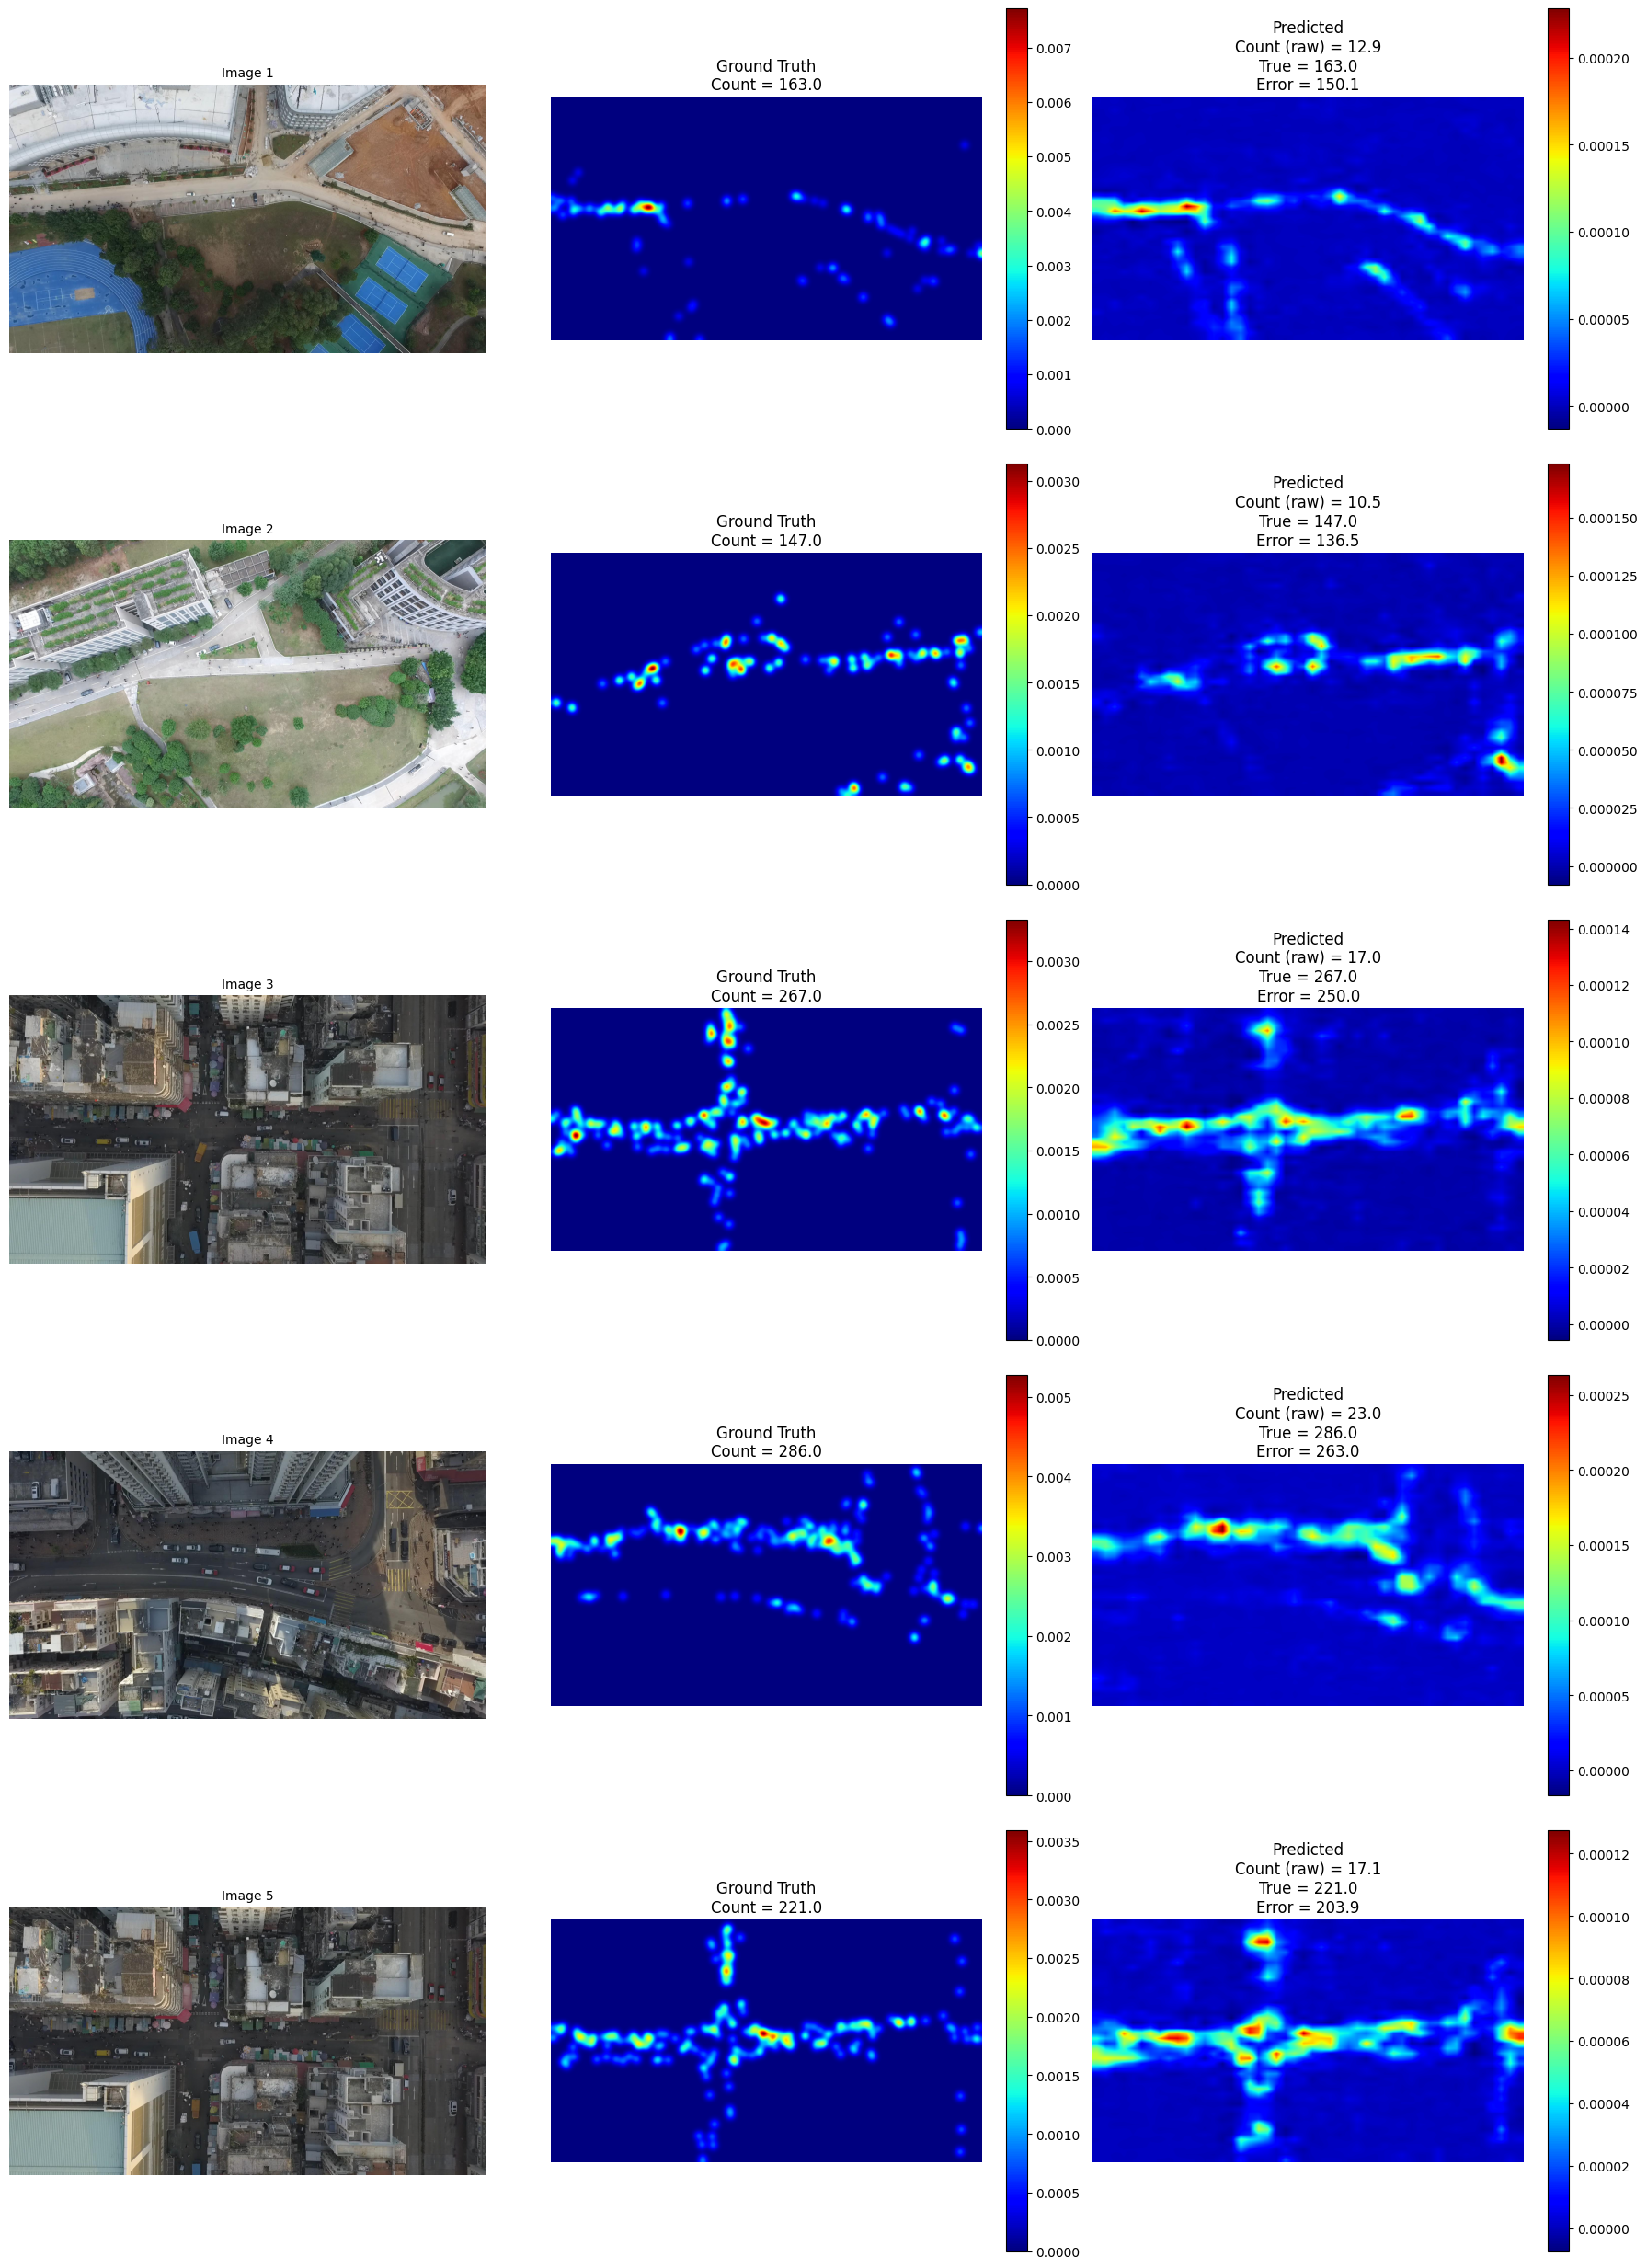


Image                          True     Predicted  Error   
------------------------------------------------------------
VisDrone_00003_00004.jpg       163.0    12.9       150.1   
VisDrone_00019_00012.jpg       147.0    10.5       136.5   
VisDrone_00066_00007.jpg       267.0    17.0       250.0   
VisDrone_00014_00030.jpg       286.0    23.0       263.0   
VisDrone_00066_00026.jpg       221.0    17.1       203.9   


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import torch
import os
from torchvision import transforms
import torch.nn.functional as F

# التأكد من أن النموذج في وضع التقييم
model.eval()

# تعريف التحويلات (إن لم تكن معرفة)
if 'transform_test' not in dir():
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

# عدد الصور العشوائية
N = 5
indices = random.sample(range(len(val_ds)), N)

fig, axes = plt.subplots(N, 3, figsize=(18, N * 5))
predictions = []

for i, idx in enumerate(indices):
    img_path, gt_path = val_ds.samples[idx]
    
    # --- الصورة الأصلية ---
    img_orig = Image.open(img_path).convert('RGB')
    
    # --- Ground Truth Density ---
    gt_density = np.load(gt_path)
    true_count = gt_density.sum()
    
    # --- تجهيز الصورة للنموذج ---
    img_resized = img_orig.resize((384, 384), Image.BICUBIC)
    img_tensor = transform_test(img_resized).unsqueeze(0).to(device)
    
    # --- تنبؤ النموذج ---
    with torch.no_grad():
        out = model(img_tensor)           # shape: (1,1,48,48)
        pred_count = out.sum().item() 
    # حساب العدد مباشرة من خريطة المخرجات (لا حاجة لرفع الدقة)
    pred_count_from_output = out.sum().item()
    
    # لرفع الدقة للعرض مع الحفاظ على المجموع:
    # - نرفع الدقة باستخدام upsample (bilinear)
    # - ثم نقسم على مربع عامل الرفع (لأن المساحة تزيد)
    orig_h, orig_w = gt_density.shape[:2]
    scale_h = orig_h / 48.0
    scale_w = orig_w / 48.0
    upsampled = F.interpolate(out, size=(orig_h, orig_w), mode='bilinear', align_corners=False)
    # تصحيح المجموع: نقسم على (scale_h * scale_w) لأنه عند الرفع bilinear المجموع يتضاعف تقريباً بهذا المقدار
    corrected_for_display = upsampled / (scale_h * scale_w)
    pred_density_display = corrected_for_display[0,0].cpu().numpy()
    pred_count_display = pred_density_display.sum()
    
    # نعتمد على العدد المحسوب من output الأصلي (دون رفع) كأفضل تقدير
    pred_count = pred_count_from_output
    
    predictions.append((os.path.basename(img_path), true_count, pred_count))
    
    # عرض الصورة الأصلية
    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title(f"Image {i+1}", fontsize=10)
    axes[i, 0].axis('off')
    
    # عرض Ground Truth
    im_gt = axes[i, 1].imshow(gt_density, cmap='jet')
    axes[i, 1].set_title(f"Ground Truth\nCount = {true_count:.1f}")
    axes[i, 1].axis('off')
    plt.colorbar(im_gt, ax=axes[i, 1], fraction=0.046)
    
    # عرض الخريطة المتوقعة بعد المعالجة (للتصور فقط)
    im_pred = axes[i, 2].imshow(pred_density_display, cmap='jet')
    axes[i, 2].set_title(f" = \n Count = {true_count:.1f}")
    axes[i, 2].axis('off')
    plt.colorbar(im_pred, ax=axes[i, 2], fraction=0.046)

plt.tight_layout()
plt.show()

# طباعة الجدول
print(f"\n{'Image':<30} {'True':<8} {'Predicted':<10} {'Error':<8}")
print("-" * 60)
for img_name, true_c, pred_c in predictions:
    print(f"{img_name:<30} {true_c:<8.1f} {pred_c:<10.1f} {abs(true_c-pred_c):<8.1f}")

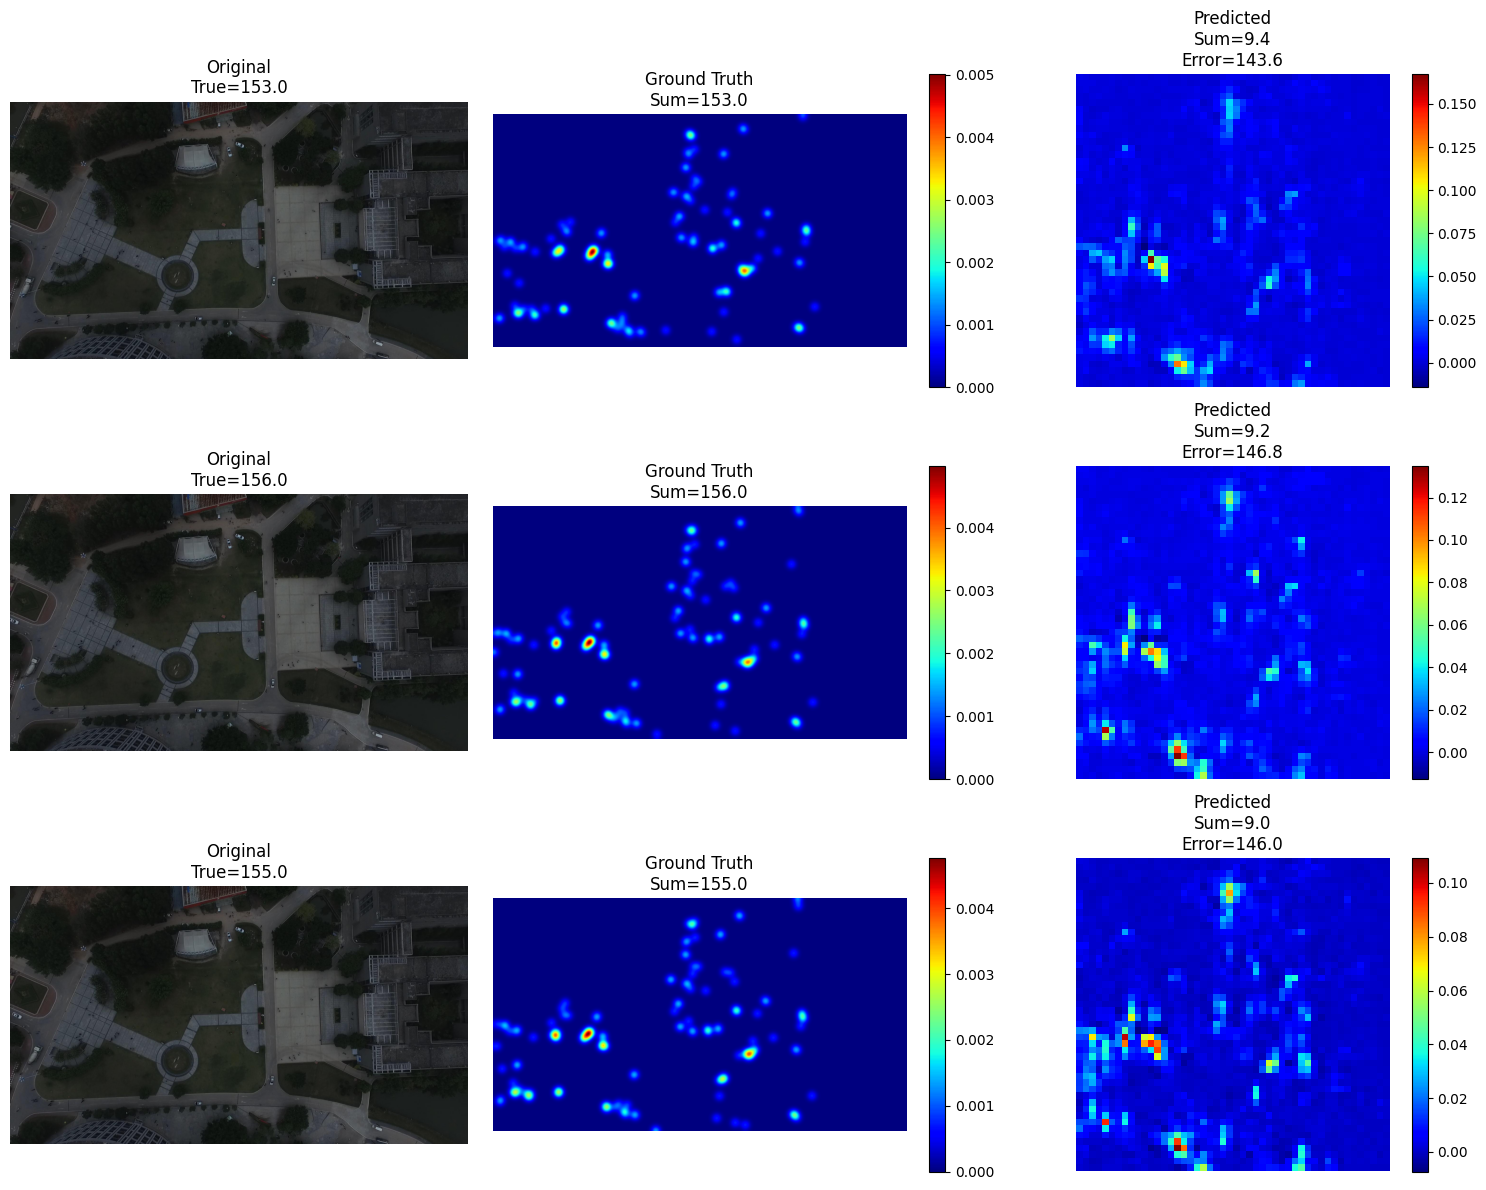

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

model.eval()
# اختر ثلاثة أمثلة: واحد بنسبة منخفضة (~8) وواحد بنسبة متوسطة وواحد بنسبة عالية (~15)
sample_indices = [1, 2, 4]  # حسب ترتيب النتائج أعلاه: index 1 (25→3.1, ratio 8), index 2 (135→9.4, ratio 14.3), index 4 (27→3.4, ratio 7.8)
labels = ["Low density (true=25, ratio~8)", "High density (true=135, ratio~14)", "Low density (true=27, ratio~8)"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, idx in enumerate(sample_indices):
    img_path, gt_path = val_ds.samples[idx]
    img = Image.open(img_path).convert('RGB')
    gt = np.load(gt_path)
    true_cnt = gt.sum()
    
    # التنبؤ
    img_resized = img.resize((384,384), Image.BICUBIC)
    inp = transform_test(img_resized).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(inp)
    pred_cnt = out.sum().item()
    pred_density = out[0,0].cpu().numpy()
    
    # عرض الصورة الأصلية
    axes[i,0].imshow(img)
    axes[i,0].set_title(f"Original\nTrue={true_cnt:.1f}")
    axes[i,0].axis('off')
    # عرض GT
    im1 = axes[i,1].imshow(gt, cmap='jet')
    axes[i,1].set_title(f"Ground Truth\nSum={true_cnt:.1f}")
    axes[i,1].axis('off')
    plt.colorbar(im1, ax=axes[i,1], fraction=0.046)
    # عرض التنبؤ
    im2 = axes[i,2].imshow(pred_density, cmap='jet')
    axes[i,2].set_title(f"Predicted\nSum={pred_cnt:.1f}\nError={abs(true_cnt-pred_cnt):.1f}")
    axes[i,2].axis('off')
    plt.colorbar(im2, ax=axes[i,2], fraction=0.046)

plt.tight_layout()
plt.show()